This notebook calls the MCMC MCP server via the `MCPClient.run_agent_loop()` to create an MCMC input file.

In [1]:
# Load needed modules
from mcp_client import MCPClient
import sys
import asyncio
import json
import traceback
import os

In [12]:
# ---------------------------------------------------------------------------
# Configuration – edit these values before running the notebook
# ---------------------------------------------------------------------------

# Model selection: change MODEL to switch providers.
# The provider is auto-detected from the model name prefix.
# Make sure the corresponding API key is set in your .env or environment.
#
#   Anthropic  (ANTHROPIC_API_KEY)
# MODEL = "claude-sonnet-4-5-20250929"
# MODEL = "claude-opus-4-6"
#
#   OpenAI  (OPENAI_API_KEY)
# MODEL = "gpt-4o"
# MODEL = "gpt-4o-mini"
#
#   Google Gemini  (GOOGLE_API_KEY)
# MODEL = "gemini-2.5-flash"
# MODEL = "gemini-2.5-pro"
MODEL = "gemini-3.1-flash-lite-preview"

server_path = "./mcmc_mcp_server.py"

mcmc_prompt = (
    "You are a helpful assistant to run MCMC chains and help tune the hyperparameters"
    "To run an MCMC chain, you first need to generate its input file, which is named by default 'my_mcmc_input.json' in the folder 'my_mcmc_test'"
    "All input and output files from this analysis should be stored in this same folder."
    "Run a 1000 sample MCMC chain and have it use gamma = 0.5 and write the samples to 'my_mcmc_samples_0.dat' in that same folder."
    "when the run is done, tell me what the acceptance rate was."
    "Ideally, we want the acceptance rate to be between 0.2 and 0.4."
    "To get a higher acceptance rate, decrease gamma. To get a lower acceptance rate, increase gamma."
    "Valid gamma values should be between 0 and 1. If you can't get a good acceptance rate in this range, do the best you can."
    "Keep running additional chains of 1000 samples by restarting from the previous chains and adjusting gamma until you have a good acceptance rate."
    "For each new run, restart from the previous run, and give the file names a sequence number so they are all consecutively named."
    "Once you have a good acceptance rate, run a long chain of 10000 samples."
    "Explain your thinking at each step and report completion when done."
)

In [13]:
# Run the agentic loop

client = MCPClient(model=MODEL)
try:
    await client.connect_to_server(server_path)
    result = await client.run_agent_loop(user_prompt=mcmc_prompt, max_turns=50)
    output = {"success": True, "result": result}
except Exception as e:
    output = {"success": False, "error": str(e), "traceback": traceback.format_exc()}
finally:
    try:
        await client.cleanup()
    except Exception as e:
        print("Warning during cleanup:", type(e).__name__, str(e), file=sys.stderr)
        traceback.print_exc(file=sys.stderr)

print(json.dumps(output, indent=2))


Connected to server with tools: ['create_mcmc_input_file', 'run_mcmc_run', 'get_acceptance_rate', 'thinking', 'task_finished']
Using model : gemini-3.1-flash-lite-preview
Provider    : google

--- Agent Turn 1 ---
Invoking tool: thinking with args: {'thought': "I will create the first MCMC input file 'my_mcmc_test/my_mcmc_input.json' with nmcmc=1000, gamma=0.5, and output file 'my_mcmc_test/my_mcmc_samples_0.dat'. Then I will run it and check the acceptance rate."}

--- Agent Turn 2 ---
Invoking tool: create_mcmc_input_file with args: {'gamma': 0.5, 'output_file': 'my_mcmc_test/my_mcmc_samples_0.dat', 'nmcmc': 1000, 'output_path': 'my_mcmc_test/my_mcmc_input.json'}

--- Agent Turn 3 ---
Invoking tool: run_mcmc_run with args: {'input_file': 'my_mcmc_test/my_mcmc_input.json'}

--- Agent Turn 4 ---
Invoking tool: thinking with args: {'thought': 'It seems I made an assumption about where `mcmc_run.py` is located. I should try running it from the root directory or correct the path. Wait, t

In [14]:
# ---------------------------------------------------------------------------
# Extract output file paths from the completed agent run.
#
# client.tool_results is a list of dicts, one per tool call:
#   {"name": str, "args": dict, "result": dict | str}
#
# The MCP tools that know about file paths:
#   create_mcmc_input_file  → result["results"]["parameters"]["output_file"]
#   run_mcmc_run            → result["results"]["run_directory"] + args["input_file"]
#
# We collect every samples file that was written during the run.
# ---------------------------------------------------------------------------

mcmc_samples_files = []

for tr in client.tool_results:
    if tr["name"] == "create_mcmc_input_file":
        try:
            params = tr["result"]["results"]["parameters"]
            run_dir = tr["result"]["results"]["run_directory"]
            output_file = params["output_file"]
            # Resolve relative paths against the input file's directory
            if not os.path.isabs(output_file):
                output_file = os.path.join(run_dir, output_file)
            mcmc_samples_files.append(output_file)
        except (KeyError, TypeError):
            pass

import os
print("MCMC samples files written during this run:")
for f in mcmc_samples_files:
    print(f"  {f}")


MCMC samples files written during this run:
  /Users/bert/Sandia_Repos/agentic_mcp/pytuq-mcmc/my_mcmc_test/my_mcmc_samples_0.dat
  /Users/bert/Sandia_Repos/agentic_mcp/pytuq-mcmc/my_mcmc_test/my_mcmc_samples_1.dat
  /Users/bert/Sandia_Repos/agentic_mcp/pytuq-mcmc/my_mcmc_test/my_mcmc_samples_2.dat
  /Users/bert/Sandia_Repos/agentic_mcp/pytuq-mcmc/my_mcmc_test/my_mcmc_samples_3.dat
  /Users/bert/Sandia_Repos/agentic_mcp/pytuq-mcmc/my_mcmc_test/my_mcmc_samples_final.dat


  my_mcmc_samples_0.dat                     samples      0 –   1000  (1001 rows)
  my_mcmc_samples_1.dat                     samples   1001 –   2001  (1001 rows)
  my_mcmc_samples_2.dat                     samples   2002 –   3002  (1001 rows)
  my_mcmc_samples_3.dat                     samples   3003 –   4003  (1001 rows)
  my_mcmc_samples_final.dat                 samples   4004 –  14004  (10001 rows)

Total samples : 14005
Parameters    : ['param_0', 'param_1']


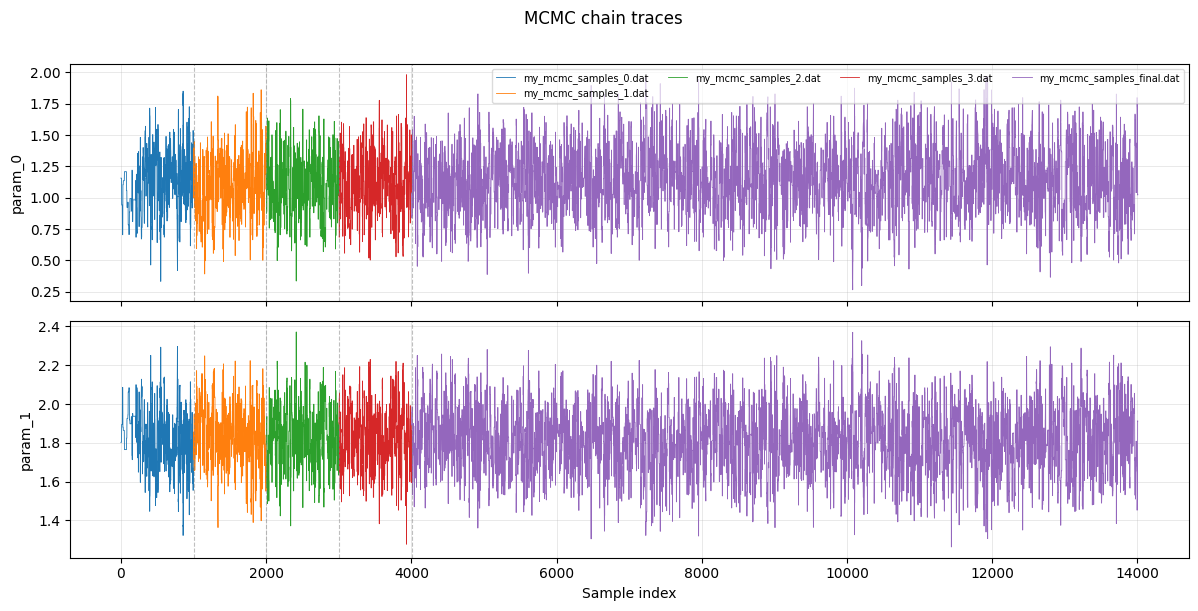

In [15]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Parse a samples .dat file → (col_names, data_array)
# ---------------------------------------------------------------------------

def _read_samples(filepath):
    """Return (col_names: list[str], data: np.ndarray) for a samples .dat file."""
    col_names = None
    data_lines = []
    with open(filepath) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("#"):
                content = line[1:].strip()
                # Column-name line contains commas; key=value lines do not
                if "," in content:
                    col_names = [c.strip() for c in content.split(",")]
            elif line.strip():
                data_lines.append(line)
    if col_names is None:
        raise ValueError(f"No column-name header found in '{filepath}'")
    data = np.loadtxt(data_lines, delimiter=",")
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return col_names, data


# ---------------------------------------------------------------------------
# Load and concatenate all sample files in order
# ---------------------------------------------------------------------------

# Filter to files that actually exist (guards against stale paths)
existing_files = [f for f in mcmc_samples_files if os.path.isfile(f)]

if not existing_files:
    print("No sample files found. Run the agent loop first.")
else:
    segments = []      # (start_index, end_index) for boundary markers
    all_chunks = []
    col_names = None

    for fpath in existing_files:
        names, chunk = _read_samples(fpath)
        if col_names is None:
            col_names = names
        # Use the index column (col 0) to track positions
        start = int(chunk[0, 0])
        end   = int(chunk[-1, 0])
        segments.append((start, end, os.path.basename(fpath)))
        all_chunks.append(chunk)
        print(f"  {os.path.basename(fpath):40s}  samples {start:6d} – {end:6d}  ({len(chunk)} rows)")

    # Concatenate; keep the original index column for the x-axis
    all_samples = np.vstack(all_chunks)
    global_index = all_samples[:, 0]

    # Parameter columns (everything after the index column)
    param_names = col_names[1:]
    param_data  = all_samples[:, 1:]
    n_params    = len(param_names)

    print(f"\nTotal samples : {len(all_samples)}")
    print(f"Parameters    : {param_names}")

    # ---------------------------------------------------------------------------
    # Trace plots: one subplot per parameter
    # ---------------------------------------------------------------------------

    fig, axes = plt.subplots(n_params, 1, figsize=(12, 3 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    # Colours for chain segments
    seg_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, name, col in zip(axes, param_names, param_data.T):
        # Draw each chain segment in its own colour
        for i, (s_start, s_end, fname) in enumerate(segments):
            mask = (global_index >= s_start) & (global_index <= s_end)
            ax.plot(global_index[mask], col[mask],
                    lw=0.6, color=seg_colors[i % len(seg_colors)],
                    label=fname)
            # Vertical boundary line between segments
            if i > 0:
                ax.axvline(s_start, color="gray", lw=0.8, ls="--", alpha=0.5)

        ax.set_ylabel(name)
        ax.grid(True, lw=0.4, alpha=0.5)

    axes[-1].set_xlabel("Sample index")
    axes[0].legend(fontsize=7, ncol=min(len(segments), 4),
                   loc="upper right", framealpha=0.7)
    fig.suptitle("MCMC chain traces", y=1.01)
    plt.tight_layout()
    plt.show()
